<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/Risk_Assessment/Mean_Reversion_Montecarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Capital: 100000€
Expected Year-End Balance: 114919.06€
Value at Risk (95% Confidence): 87454.43€
Max Potential Loss (Worst Case): 69580.33€


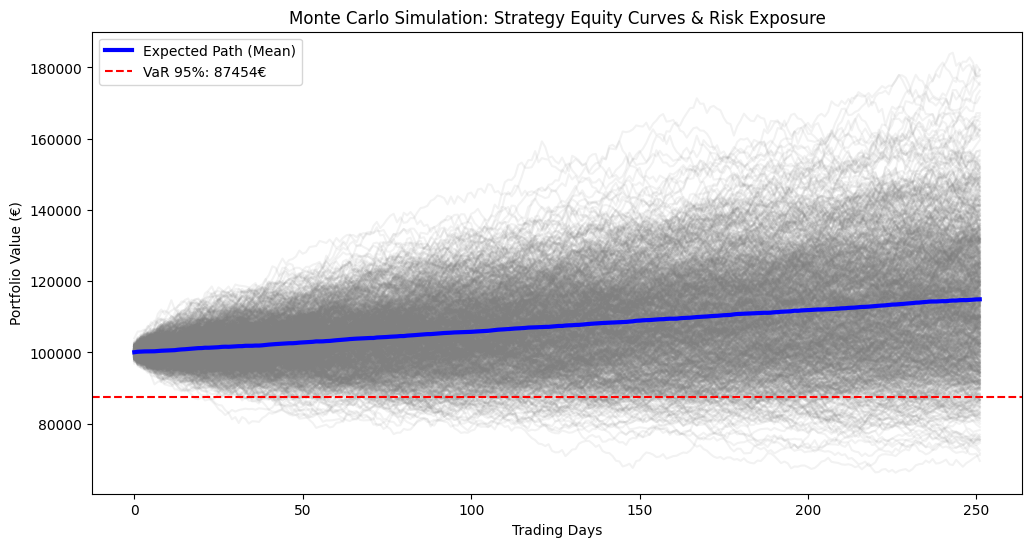

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup Parameters
np.random.seed(42)
days_to_simulate = 252  # One trading year
n_simulations = 1000
initial_capital = 100000
mu = 0.0005    # Expected daily return (approx 12% yr)
sigma = 0.01   # Daily volatility

# 2. Monte Carlo Simulation of Daily Returns
# We use a normal distribution (could be improved with Student-T for 'Fat Tails')
daily_returns = np.random.normal(mu, sigma, (days_to_simulate, n_simulations))

# 3. Strategy Logic (Risk-Adjusted Overlay)
# We assume our strategy has a 'Sharpe Ratio' edge
# Here we simulate the Equity Curves based on the returns
equity_curves = initial_capital * np.exp(np.cumsum(daily_returns, axis=0))

# 4. Calculate Risk Metrics (What Middle Office cares about)
final_returns = equity_curves[-1, :]
var_95 = np.percentile(final_returns, 5)  # Value at Risk 95%
expected_return = np.mean(final_returns)

print(f"Initial Capital: {initial_capital}€")
print(f"Expected Year-End Balance: {expected_return:.2f}€")
print(f"Value at Risk (95% Confidence): {var_95:.2f}€")
print(f"Max Potential Loss (Worst Case): {np.min(final_returns):.2f}€")

# 5. Visualization for GitHub
plt.figure(figsize=(12, 6))
plt.plot(equity_curves, color='gray', alpha=0.1)
plt.plot(equity_curves.mean(axis=1), color='blue', lw=3, label='Expected Path (Mean)')
plt.axhline(var_95, color='red', linestyle='--', label=f'VaR 95%: {var_95:.0f}€')

plt.title('Monte Carlo Simulation: Strategy Equity Curves & Risk Exposure')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value (€)')
plt.legend()
plt.show()